In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [5]:
df=pd.read_csv("nlp_posts.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2091 entries, 0 to 2090
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      2091 non-null   int64  
 1   Unnamed: 0        2091 non-null   int64  
 2   id                2091 non-null   object 
 3   title             2091 non-null   object 
 4   body              12 non-null     object 
 5   score             2091 non-null   int64  
 6   upvote_ratio      2091 non-null   float64
 7   num_comments      2091 non-null   int64  
 8   flair             2091 non-null   object 
 9   author            2091 non-null   object 
 10  url               2091 non-null   object 
 11  permalink         2091 non-null   object 
 12  created_utc       2091 non-null   object 
 13  category          2091 non-null   object 
 14  is_self_post      2091 non-null   bool   
 15  domain            2091 non-null   object 
 16  top_comments      1110 non-null   object 


In [6]:
df = df.rename(columns={
    "Dominant_topics" : "dominant_topic",
    "topic_confidance": "topic_confidence",
    "Topic_labels"    : "topic_label"
})

In [7]:
threshold   = df["score"].quantile(0.75)
df["viral"] = (df["score"] > threshold).astype(int)

In [8]:
df["created_utc"] = pd.to_datetime(df["created_utc"])
df["hour"]        = df["created_utc"].dt.hour
df["day_of_week"] = df["created_utc"].dt.dayofweek
df["day_name"]    = df["created_utc"].dt.day_name()
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

In [9]:
print("shape:", df.shape)
print("\nsentiment counts:")
print(df["sentiment"].value_counts())
print("\nviral posts:", df["viral"].sum(), "out of", len(df))

shape: (2091, 31)

sentiment counts:
sentiment
negative    1311
neutral      661
positive     119
Name: count, dtype: int64

viral posts: 523 out of 2091


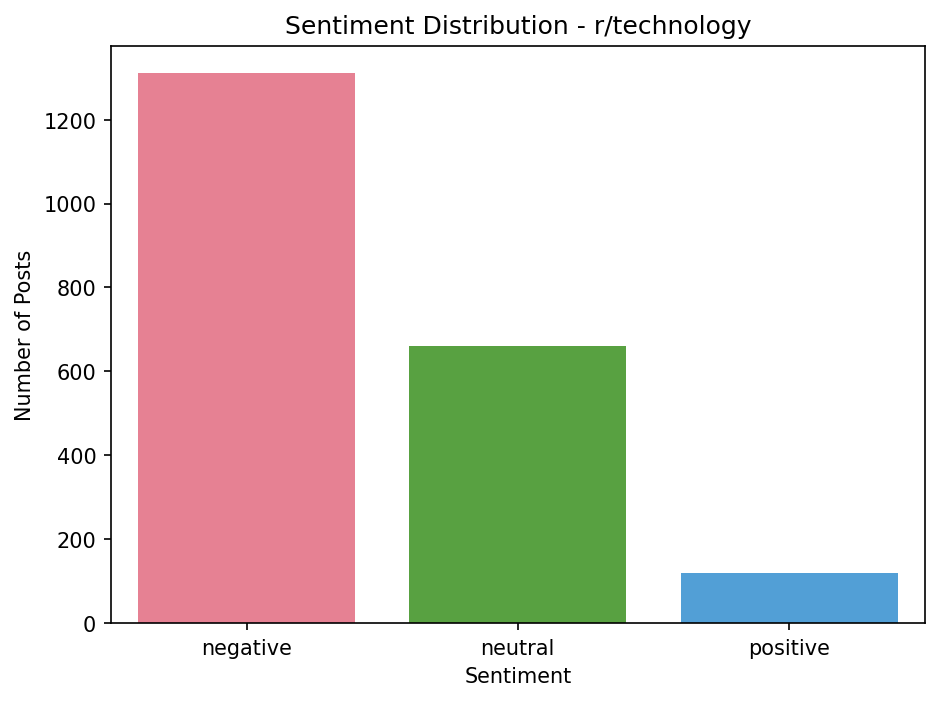

In [37]:
sentiment_counts = df["sentiment"].value_counts().reset_index()
sentiment_counts.columns = ["sentiment", "count"]

plt.figure(figsize=(7, 5),dpi=150)
sns.barplot(data=sentiment_counts, x="sentiment", y="count",hue="sentiment",legend=False,palette="husl")
plt.title("Sentiment Distribution - r/technology")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.savefig("viz_01_sentiment_distribution.png", dpi=150)
plt.show()

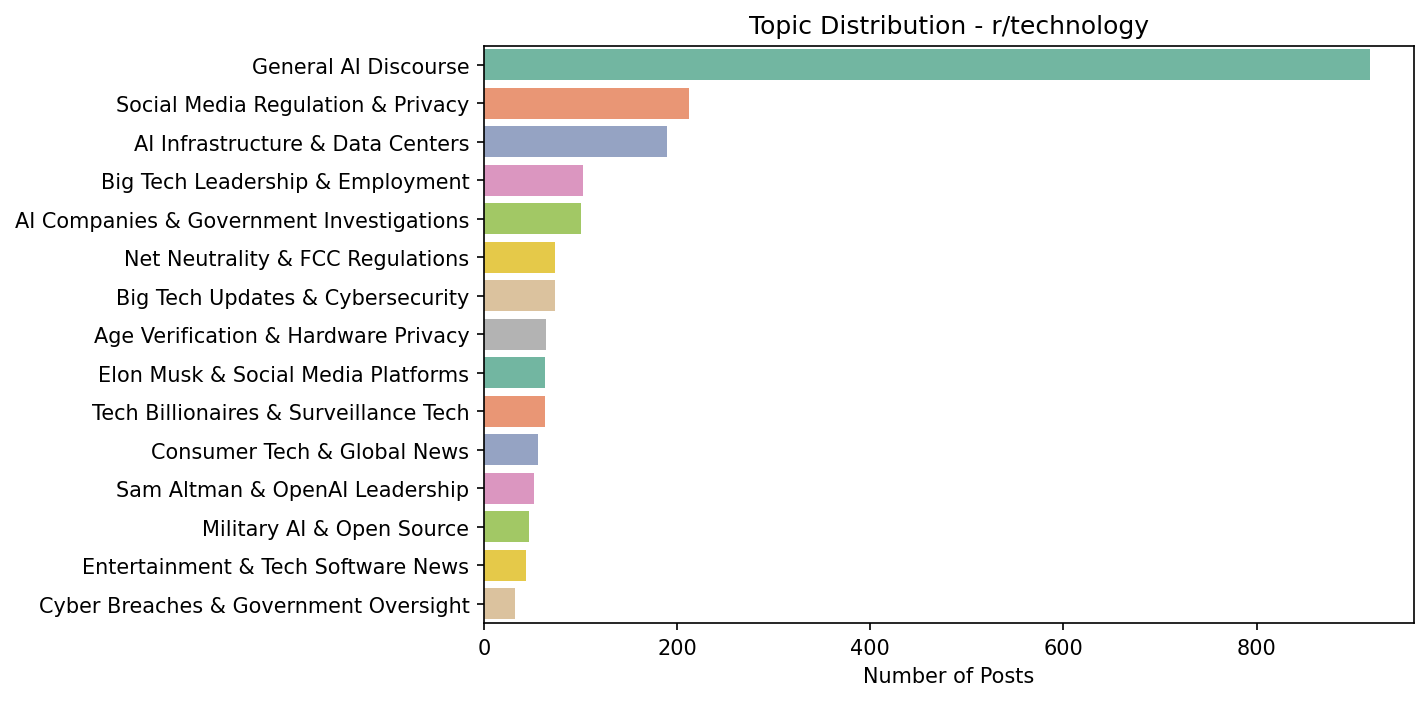

In [39]:
topic_counts = df["topic_label"].value_counts().reset_index()
topic_counts.columns = ["topic", "count"]
plt.figure(figsize=(8, 5),dpi=150)
sns.barplot(data=topic_counts, y="topic", x="count",hue="topic" ,legend=False ,palette="Set2")
plt.title("Topic Distribution - r/technology")
plt.xlabel("Number of Posts")
plt.ylabel("")
plt.savefig("viz_topic_distribution.png", dpi=150)
plt.show()

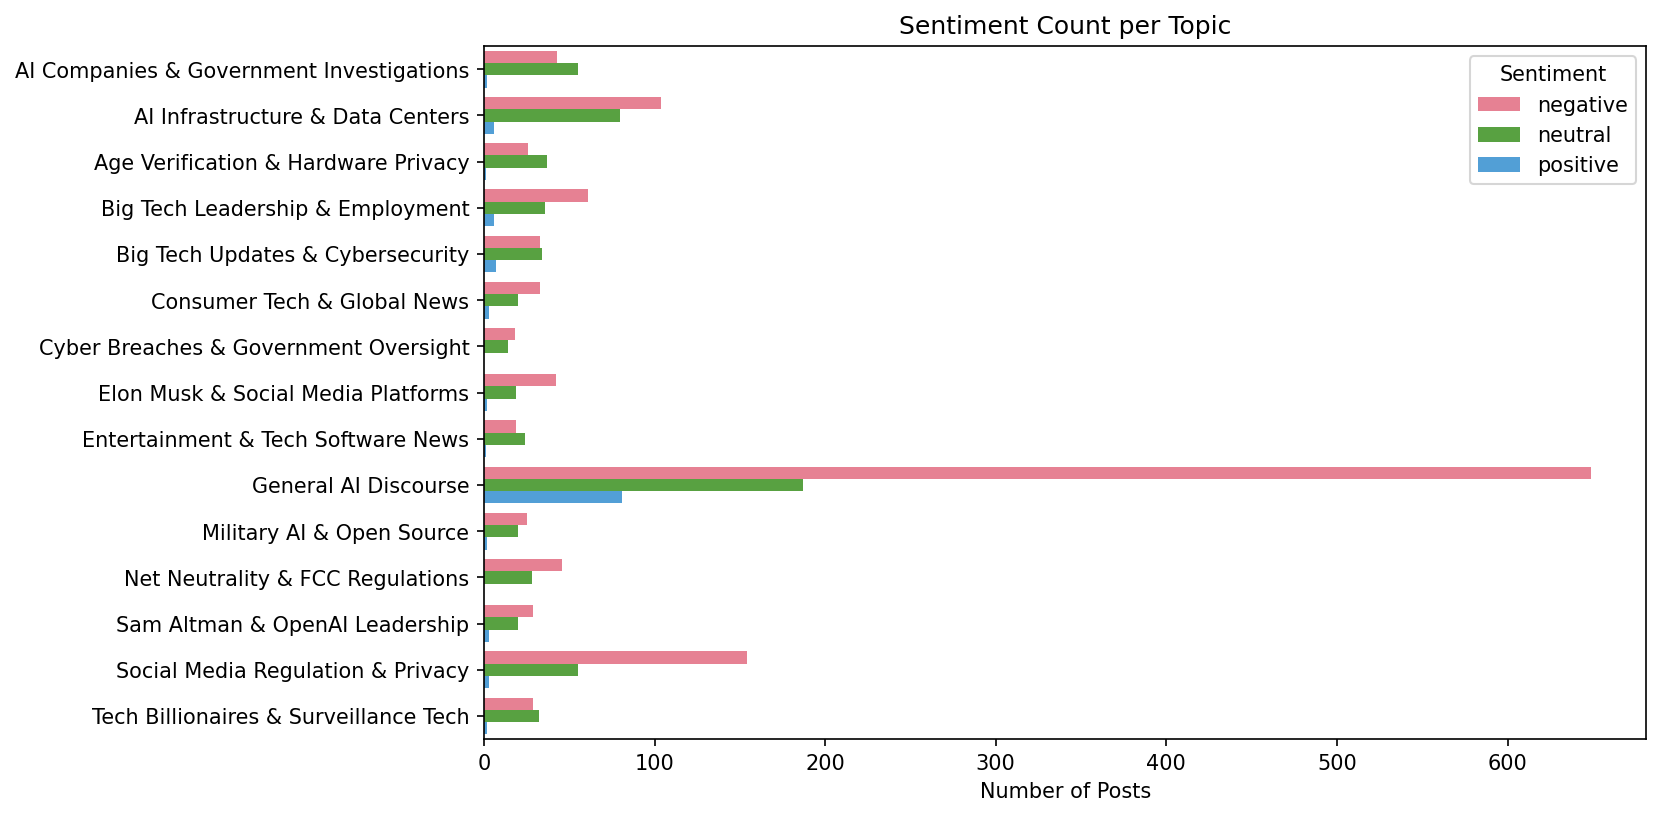

In [40]:
pivot = df.groupby(["topic_label", "sentiment"]).size().reset_index(name="count")

plt.figure(figsize=(10, 6),dpi=150)
sns.barplot(data=pivot, y="topic_label", x="count", hue="sentiment", palette="husl")
plt.title("Sentiment Count per Topic")
plt.xlabel("Number of Posts")
plt.ylabel("")
plt.legend(title="Sentiment")
plt.savefig("viz_sentiment_count_per_topic.png", dpi=150)
plt.show()

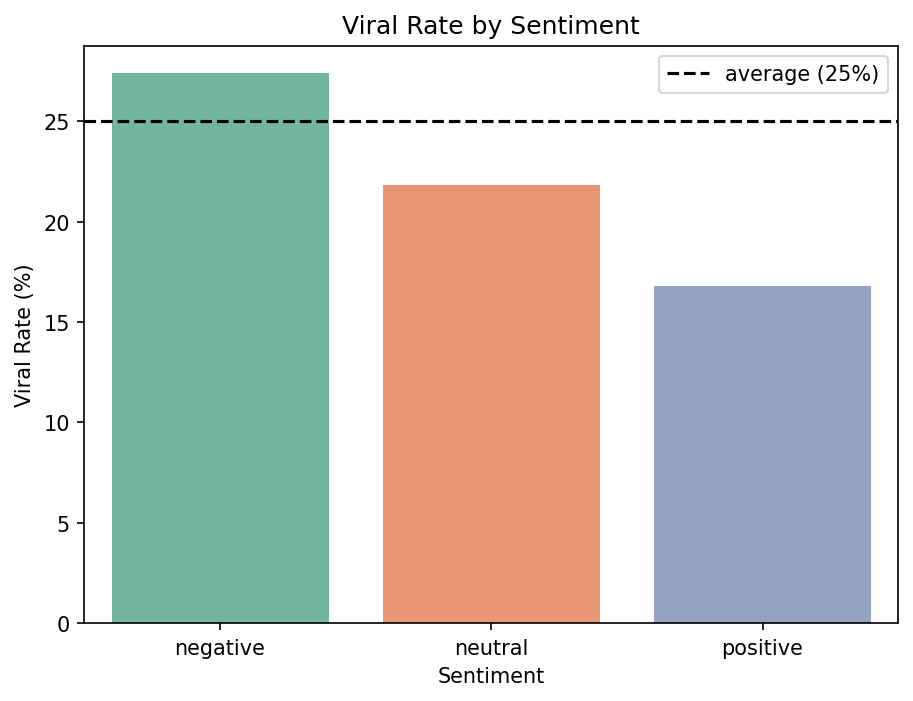

In [41]:
viral_sentiment = df.groupby("sentiment")["viral"].mean().reset_index()
viral_sentiment["viral_pct"] = (viral_sentiment["viral"] * 100).round(1)
plt.figure(figsize=(7, 5),dpi=150)
sns.barplot(data=viral_sentiment, x="sentiment", y="viral_pct",hue="sentiment",palette="Set2")
plt.axhline(25, color="black", linestyle="--", label="average (25%)")
plt.title("Viral Rate by Sentiment")
plt.ylabel("Viral Rate (%)")
plt.xlabel("Sentiment")
plt.savefig("viz_Viral_Rate_by_Sentiment.png", dpi=150)
plt.legend()
plt.show()

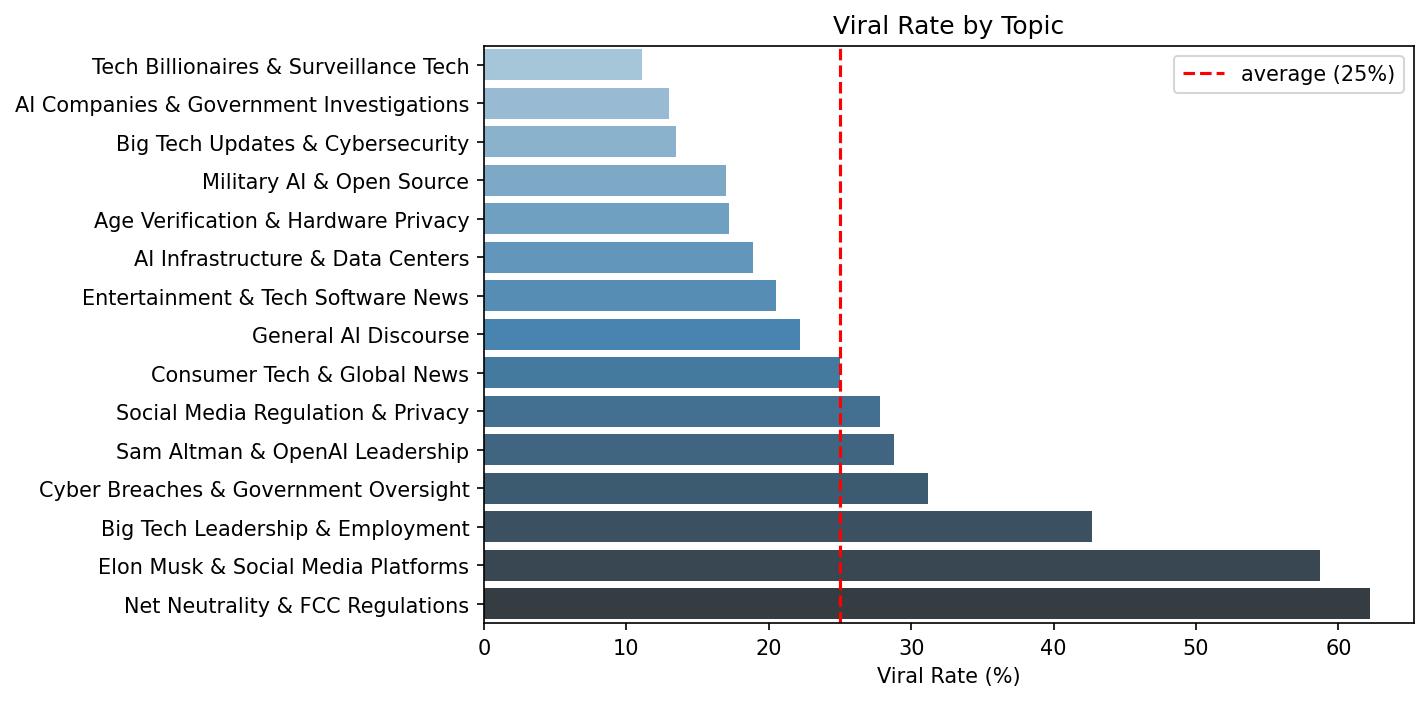

In [42]:
viral_topic = df.groupby("topic_label")["viral"].mean().reset_index()
viral_topic["viral_pct"] = (viral_topic["viral"] * 100).round(1)
viral_topic = viral_topic.sort_values("viral_pct")
plt.figure(figsize=(8, 5),dpi=150)
sns.barplot(data=viral_topic, y="topic_label", x="viral_pct",hue='topic_label',legend=False, palette="Blues_d")
plt.axvline(25, color="red", linestyle="--", label="average (25%)")
plt.title("Viral Rate by Topic")
plt.xlabel("Viral Rate (%)")
plt.ylabel("")
plt.savefig("viz_vural_rate_by_topic.png", dpi=150)
plt.legend()
plt.show()

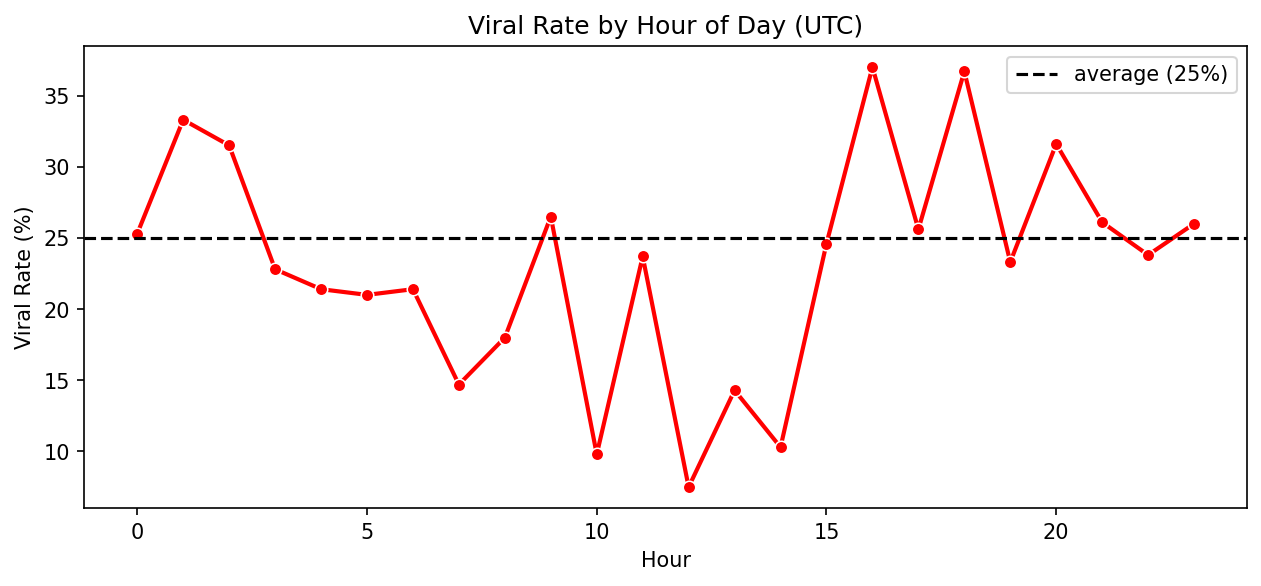

In [44]:
viral_hour = df.groupby("hour")["viral"].mean().reset_index()
viral_hour["viral_pct"] = (viral_hour["viral"] * 100).round(1)

plt.figure(figsize=(10, 4),dpi=150)
sns.lineplot(data=viral_hour, x="hour", y="viral_pct",color="red", linewidth=2, markers=True, marker="o")
plt.axhline(25, color="black", linestyle="--", label="average (25%)")
plt.title("Viral Rate by Hour of Day (UTC)")
plt.xlabel("Hour")
plt.ylabel("Viral Rate (%)")

plt.savefig("viz_viral_rate_by_hour.png", dpi=150)
plt.legend()
plt.show()

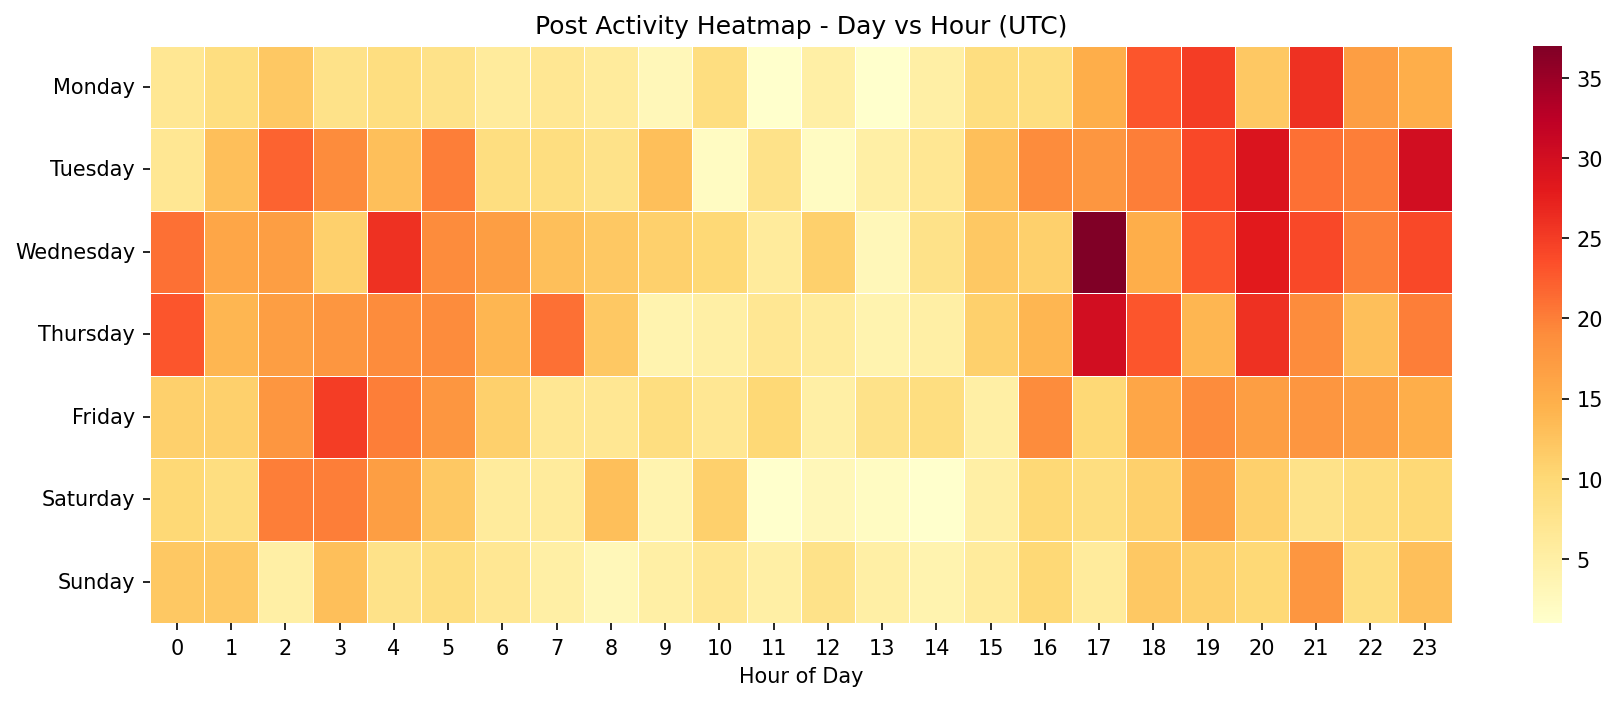

In [45]:
day_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
pivot = df.groupby(["day_name", "hour"]).size().unstack(fill_value=0)
pivot = pivot.reindex(day_order)
plt.figure(figsize=(14, 5),dpi=150)
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, linecolor="white")
plt.title("Post Activity Heatmap - Day vs Hour (UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("")

plt.savefig("viz_post_activity_heatmap.png", dpi=150)
plt.show()

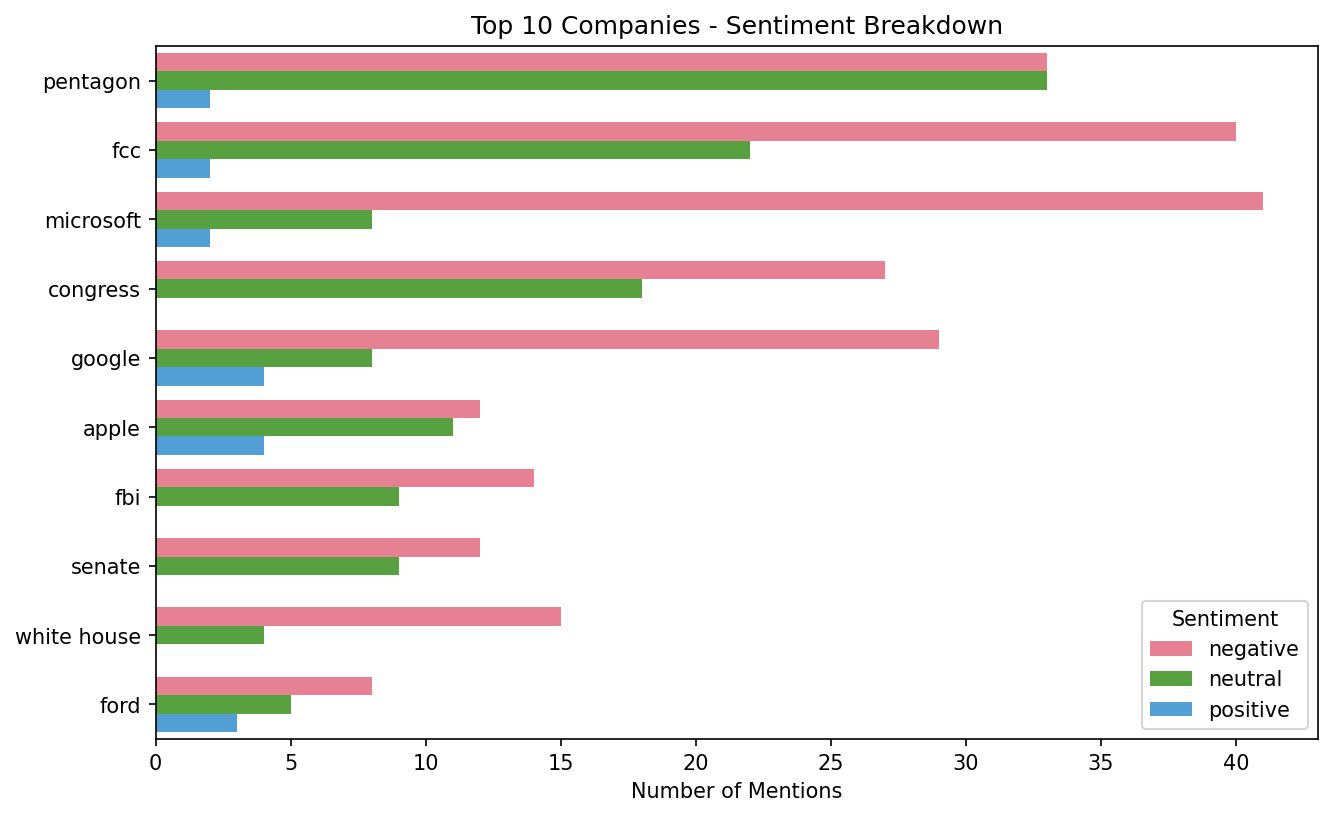

In [46]:
all_orgs = []
for _, row in df.iterrows():
    if isinstance(row["orgs"], str) and row["orgs"].strip():
        for org in row["orgs"].split(" | "):
            org = org.strip()
            if len(org) > 2:
                all_orgs.append({"org": org, "sentiment": row["sentiment"]})

orgs_df = pd.DataFrame(all_orgs)
top_orgs = orgs_df["org"].value_counts().head(10).index.tolist()
orgs_filtered = orgs_df[orgs_df["org"].isin(top_orgs)]
plt.figure(figsize=(10, 6),dpi=150)
sns.countplot(data=orgs_filtered, y="org", hue="sentiment",palette="husl",order=top_orgs)
plt.title("Top 10 Companies - Sentiment Breakdown")
plt.xlabel("Number of Mentions")
plt.ylabel("")

plt.savefig("viz_TOP10_sentiment.png", dpi=150)
plt.legend(title="Sentiment")
plt.show()

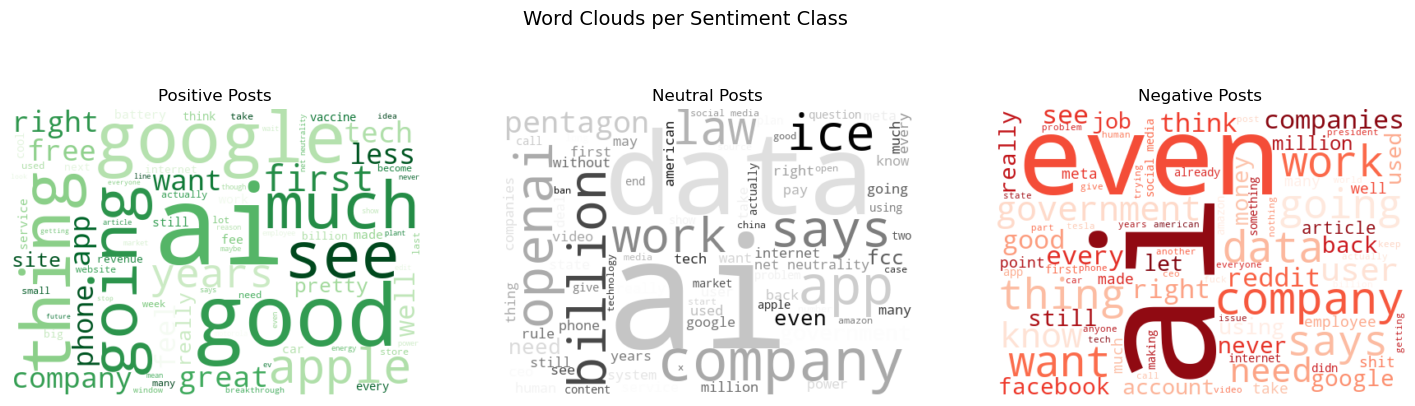

In [47]:
from wordcloud import WordCloud, STOPWORDS

# use the built-in STOPWORDS set and add custom ones on top
custom_stopwords = STOPWORDS.union({
    "will", "also", "one", "new", "say", "said",
    "use", "just", "like", "get", "got", "go",
    "make", "way", "time", "year", "day", "now",
    "that", "this", "they", "them", "their",
    "have", "has", "had", "would", "could", "should",
    "people", "us", "we", "our", "your", "my",
    "don", "don't", "it's", "i'm", "you", "he",
    "she", "re", "ve", "ll", "doesn", "isn",
    "anthropic", "trump", "wa", "ha" ,"s", "u", "t", "a", "i", "m", "b" 
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sentiment_colors = {
    "positive": "Greens",
    "neutral":  "Greys",
    "negative": "Reds"
}

for ax, sentiment in zip(axes, ["positive", "neutral", "negative"]):
    text = " ".join(df[df["sentiment"] == sentiment]["clean_text"].dropna().values)

    wc = WordCloud(
        width=500, height=350,
        background_color="white",
        colormap=sentiment_colors[sentiment],
        max_words=80,
        stopwords=custom_stopwords
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{sentiment.capitalize()} Posts")

plt.suptitle("Word Clouds per Sentiment Class", fontsize=14)

plt.savefig("viz_wordcloud_per_sentiment.png", dpi=150)
plt.show()

In [35]:
print("=" * 55)
print("PROJECT INSIGHTS SUMMARY")
print("=" * 55)

neg_pct = (df["sentiment"] == "negative").mean() * 100
pos_pct = (df["sentiment"] == "positive").mean() * 100
print(f"\nSENTIMENT")
print(f"  {neg_pct:.1f}% posts are negative")
print(f"  {pos_pct:.1f}% posts are positive")

viral_neg = df[df["sentiment"] == "negative"]["viral"].mean() * 100
viral_pos = df[df["sentiment"] == "positive"]["viral"].mean() * 100
print(f"\nVIRALITY + SENTIMENT")
print(f"  Negative posts viral rate : {viral_neg:.1f}%")
print(f"  Positive posts viral rate : {viral_pos:.1f}%")
print(f"  Finding: negative posts go slightly more viral")

top_viral_topic = df.groupby("topic_label")["viral"].mean().idxmax()
print(f"\nTOPICS")
print(f"  Most viral topic    : {top_viral_topic}")
print(f"  Most discussed topic: {df['topic_label'].value_counts().idxmax()}")

peak_hour = df.groupby("hour")["viral"].mean().idxmax()
print(f"\nTIMING")
print(f"  Best hour to post (UTC): {peak_hour}:00")
print(f"  Weekday viral rate : {df[df['is_weekend']==0]['viral'].mean()*100:.1f}%")
print(f"  Weekend viral rate : {df[df['is_weekend']==1]['viral'].mean()*100:.1f}%")

print(f"\nMODEL")
print(f"  Best model : Logistic Regression")
print(f"  ROC AUC    : 0.7833")
print(f"  Top feature: title_length")
print(f"  Finding    : negative sentiment slightly predicts virality")

PROJECT INSIGHTS SUMMARY

SENTIMENT
  62.7% posts are negative
  5.7% posts are positive

VIRALITY + SENTIMENT
  Negative posts viral rate : 27.4%
  Positive posts viral rate : 16.8%
  Finding: negative posts go slightly more viral

TOPICS
  Most viral topic    : Net Neutrality & FCC Regulations
  Most discussed topic: General AI Discourse

TIMING
  Best hour to post (UTC): 16:00
  Weekday viral rate : 24.4%
  Weekend viral rate : 27.3%

MODEL
  Best model : Logistic Regression
  ROC AUC    : 0.7833
  Top feature: title_length
  Finding    : negative sentiment slightly predicts virality
